In [ ]:
from pathlib import Path
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from collections import defaultdict
from matplotlib.ticker import FuncFormatter



In [4]:
pd.options.display.float_format = '{:,.2f}'.format  
# format all float columns in DataFrames to show 2 decimal places with thousand separators

In [5]:
# loading in the data
doge_cuts = pd.read_csv("data/clean_cuts.csv")

In [6]:
# function to parse the savings and contract total column
def parse_money(x):
	if pd.isna(x):
		return 0.0
	s = str(x).strip()
	s = s.replace("$", "").replace(",", "")
	try:
		return float(s)
	except ValueError:
		return 0.0
	
# parse savings into numeric
doge_cuts["savings_num"] = doge_cuts.get("savings").apply(parse_money)
# parse savings into numeric
doge_cuts["total_num"] = doge_cuts.get("contract_total").apply(parse_money)


In [77]:

# keep only rows with positive savings (> 0)
doge_cuts = doge_cuts[doge_cuts["savings_num"] > 0.0]

# tokenization and stopwords
STOPWORDS = {
    'the','and','for','with','that','this','from','are','was','were','has','have','will','may',
    'use','using','used','project','projects','service','services','contract','contracts','grant',
    'grants','total','amount','fund','funds','agreement','provide','providing','agency',
    'program','through','unavailable','reasons','our','new',
    'www','com','org','net','edu','gov'
}

def tokenize(text: str):
    if pd.isna(text):
        return []
    s = str(text).lower() # getting all to lower 
    # remove URLs and common web stuff
    s = re.sub(r'https?://\S+|www\.\S+', ' ', s)
    # replace any non-word/non-space with space
    s = re.sub(r'[^\w\s]', ' ', s)
    tokens = s.split()
    tokens = [t for t in tokens if len(t) > 2 and t not in STOPWORDS and not t.isdigit()]
    return tokens

cnt_contract = Counter() # begining count

cnt_grant = Counter() # begining count

# iterate over contract descriptions and count word frequencies
if "contract_description" in doge_cuts.columns:
    for val in doge_cuts["contract_description"].dropna().astype(str):
        cnt_contract.update(tokenize(val))

# iterate over grant descriptions and count word frequencies
if "grant_description" in doge_cuts.columns:
    for val in doge_cuts["grant_description"].dropna().astype(str):
        cnt_grant.update(tokenize(val))

# prepare outputs
top_contract = pd.DataFrame(cnt_contract.most_common(100), columns=["word", "count"])
top_grant = pd.DataFrame(cnt_grant.most_common(100), columns=["word", "count"])

top_contract.to_csv("data/top_contract_words.csv", index=False)
top_grant.to_csv("data/top_grant_words.csv", index=False)

print(f"Saved top 100 contract words")
print(f"Saved top 100 grant words")



Saved top 100 contract words
Saved top 100 grant words


In [1]:
# original institution names (as provided) - we'll normalize by removing dashes
raw_targets = [
    "columbia-university",
    "northwestern-university",
    "portland-state-university",
    "university-of-california",
    "university-of-minnesota",
    "american-university",
    "university-of-massachusetts",
    "yale-university",
    "university-of-washington",
    "arizona-state-university",
    "boise-state-university",
    "carnegie-mellon-university",
    "clemson-university",
    "cornell-university",
    "duke-university",
    "emory-university",
    "george-mason-university",
    "georgetown-university",
    "grand-valley-state-university",
    "massachusetts-institute-of-technology",
    "montana-state-university",
    "new-york-university",
    "ohio-state-university",
    "rice-university",
    "rutgers-university",
    "tulane-university-of-louisiana",
    "university-of-alabama",
    "university-of-arkansas",
    "university-of-chicago",
    "university-of-cincinnati",
    "university-of-colorado",
    "university-of-delaware",
    "university-of-kansas",
    "university-of-michigan",
    "university-of-nebraska",
    "university-of-new-mexico",
    "university-of-north-dakota",
    "university-of-north-texas",
    "university-of-notre-dame",
    "university-of-nevada",
    "university-of-oklahoma",
    "university-of-oregon",
    "university-of-rhode-island",
    "university-of-south-florida",
    "univetrsity-of-utah",
    "university-washington",
    "university-of-wisconsin",
    "vanderbilt-university",
    "washington-state-university",
    "george-washington-university",
    "harvard-university",
    "university-of-louisville",
    "university-of-miami",
    "western-michigan-university",
    "university-of-pennsylvania",
    "university-of-maryland",
]

# produce cleaned targets with dashes removed (replace with spaces)
cleaned_targets = [t.replace('-', ' ').strip() for t in raw_targets]

def normalize_for_search(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).lower()
    # replace non-alphanumeric characters with spaces (removes dashes)
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = s.strip()
    # collapse spaces
    s = re.sub(r"\s+", " ", s)
    return s
    
# pre-normalize targets (dash-free, lowercased, spaces collapsed)
norm_targets = [normalize_for_search(t) for t in cleaned_targets]

# create working copy and add normalized vendor/details columns for matching
doge_cuts = doge_cuts.copy()
doge_cuts["vendor_n"] = doge_cuts.get("vendor", "").apply(normalize_for_search)
doge_cuts["full_details_n"] = doge_cuts.get("full_details", "").apply(normalize_for_search)

# iterate through each row to find institution matches
matches = []
for i, row in doge_cuts.iterrows():
    v = str(row.get("vendor_n", ""))
    f = str(row.get("full_details_n", ""))
    matched_terms = []
    matched_fields = []
    
    # check if any normalized target appears in vendor or full_details
    for t, nt in zip(cleaned_targets, norm_targets):
        if nt and (nt in v or nt in f):
            matched_terms.append(t)  # store original cleaned name
            # track which field(s) matched
            if nt in v:
                matched_fields.append("vendor")
            if nt in f:
                matched_fields.append("full_details")
    
    # only keep rows with at least one match
    if matched_terms:
        out_row = row.to_dict()
        out_row["matched_terms"] = ";".join(sorted(set(matched_terms)))
        out_row["matched_fields"] = ";".join(sorted(set(matched_fields)))
        matches.append(out_row)

out_df = pd.DataFrame(matches)

# write a CSV with core columns + matched info
keep_cols = [c for c in out_df.columns if c in [
    "vendor","full_details","savings","contract_total","contract_description","grant_description","providing_agency"
]]
keep_cols += ["matched_terms","matched_fields"]

# ensure unique columns order
keep_cols = [c for c in keep_cols if c in out_df.columns]
out_df.to_csv("data/institution_cuts.csv", columns=keep_cols, index=False)
print(f"Saved {len(out_df)} rows matching insitutions")


NameError: name 'pd' is not defined

In [ ]:
# stop words list
STOPWORDS = {
    'the','and','for','with','that','this','from','are','was','were','has','have','will','may',
    'use','using','used','project','projects','service','services','contract','contracts','grant',
    'grants','total','amount','fund','funds','agreement','provide','providing','agency',
    'program','through','unavailable','reasons','our','new',
    'www','com','org','net','edu','gov',
    'university','college','school','center','department','office'
}
# updated tokenize function with regex collapsing for multi-word terms
def tokenize(text: str):
    if pd.isna(text):
        return []
    s = str(text).lower()
    # remove URLs and web references
    s = re.sub(r'https?://\S+|www\.\S+', ' ', s)
    # collapse 'anti-semitism' variants (with/without hyphen/space) into single token
    s = re.sub(r'\banti[\s\-]*semiti?sm\b', 'antisemitism', s)
    # collapse 'task force' variants (with/without hyphen/space) into single token
    s = re.sub(r'\btask[\s\-]*force\b', 'taskforce', s)
    # replace punctuation with spaces
    s = re.sub(r'[^\w\s]', ' ', s)
    tokens = s.split()
    # filter: length > 2, not in stopwords, not all digits
    tokens = [t for t in tokens if len(t) > 2 and t not in STOPWORDS and not t.isdigit()]
    return tokens

# initialize counters for institution-specific word frequencies
cnt_contract = Counter()
cnt_grant = Counter()

# tokenize and count contract descriptions
if "contract_description" in doge_cuts.columns:
    for val in doge_cuts["contract_description"].dropna().astype(str):
        cnt_contract.update(tokenize(val))

# tokenize and count grant descriptions
if "grant_description" in doge_cuts.columns:
    for val in doge_cuts["grant_description"].dropna().astype(str):
        cnt_grant.update(tokenize(val))

top_contract = pd.DataFrame(cnt_contract.most_common(100), columns=["word", "count"])
top_grant = pd.DataFrame(cnt_grant.most_common(100), columns=["word", "count"])

top_contract.to_csv("data/institution_top_contract_words.csv", index=False)
top_grant.to_csv("data/institution_top_grant_words.csv", index=False)

print(f"Saved top 100 institution contract words")
print(f"Saved top 100 institution grant words")

Saved top 100 institution contract words
Saved top 100 institution grant words


In [ ]:
# Function to generate wordcloud from CSV file with word frequencies
def make_wordcloud_from_csv(csv_path, outpath, max_words=100):
    # Read CSV and extract word-frequency pairs
    df = pd.read_csv(csv_path)
    freqs = dict(zip(df['word'].astype(str), df['count'].astype(int)))
    
    # Create wordcloud with custom parameters for better layout
    wc = WordCloud(
        width=1600,
        height=1000,
        background_color='white',
        max_words=max_words,
        margin=8,
        prefer_horizontal=0.9,  # Prefer horizontal text orientation
        collocations=False,
        random_state=42
    )
    wc.generate_from_frequencies(freqs)

    # Save wordcloud as image
    outpath.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(12, 8))
    plt.imshow(wc.to_array(), interpolation='bilinear')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved wordcloud to {outpath}")


files = [
    (Path('data/top_contract_words.csv'), Path('figures/top_contract_wordcloud.png')),
    (Path('data/top_grant_words.csv'), Path('figures/top_grant_wordcloud.png')),
    (Path('data/institution_top_contract_words.csv'), Path('figures/institution_contract_wordcloud.png')),
    (Path('data/institution_top_grant_words.csv'), Path('figures/institution_grant_wordcloud.png')),
]

for src, dst in files:
    make_wordcloud_from_csv(src, dst)

Saved wordcloud to figures\top_contract_wordcloud.png
Saved wordcloud to figures\top_grant_wordcloud.png
Saved wordcloud to figures\institution_contract_wordcloud.png
Saved wordcloud to figures\institution_grant_wordcloud.png


In [ ]:
# compute unique counts across the whole dataset
num_agencies = int(doge_cuts.get("providing_agency").dropna().astype(str).str.strip().replace('', pd.NA).dropna().nunique())
num_vendors = int(doge_cuts.get("vendor").dropna().astype(str).str.strip().replace('', pd.NA).dropna().nunique())

# compute median and max savings (exclude NaN values)
valid = doge_cuts["savings_num"].dropna()
median_savings = float(valid.median()) if not valid.empty else None
max_savings = float(valid.max()) if not valid.empty else None

# find vendor and agency associated with the maximum savings
vendor_of_max = None
agency_of_max = None
if max_savings is not None and not valid.empty:
	row = doge_cuts.loc[doge_cuts["savings_num"] == max_savings]
	if not row.empty:
		row0 = row.iloc[0]
		vendor_of_max = row0.get("vendor")
		agency_of_max = row0.get("providing_agency")

# compile results into a summary dictionary
summary = {
	"num_agencies": num_agencies,
	"num_vendors": num_vendors,
	"median_savings": median_savings,
	"max_savings": max_savings,
	"vendor_of_max_savings": vendor_of_max,
	"providing_agency_of_max_savings": agency_of_max,
}

summary_df = pd.DataFrame(list(summary.items()), columns=["metric","value"])
summary_df.to_csv("data/overall_summary", index=False)
print(f"Saved summary")

Saved summary


C:\Users\rosea\AppData\Local\Temp\ipykernel_40044\2853254085.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='word', x='count', data=df_contract, ax=axes[0], palette='Blues_d')
C:\Users\rosea\AppData\Local\Temp\ipykernel_40044\2853254085.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='word', x='count', data=df_grant, ax=axes[1], palette='Greens_d')


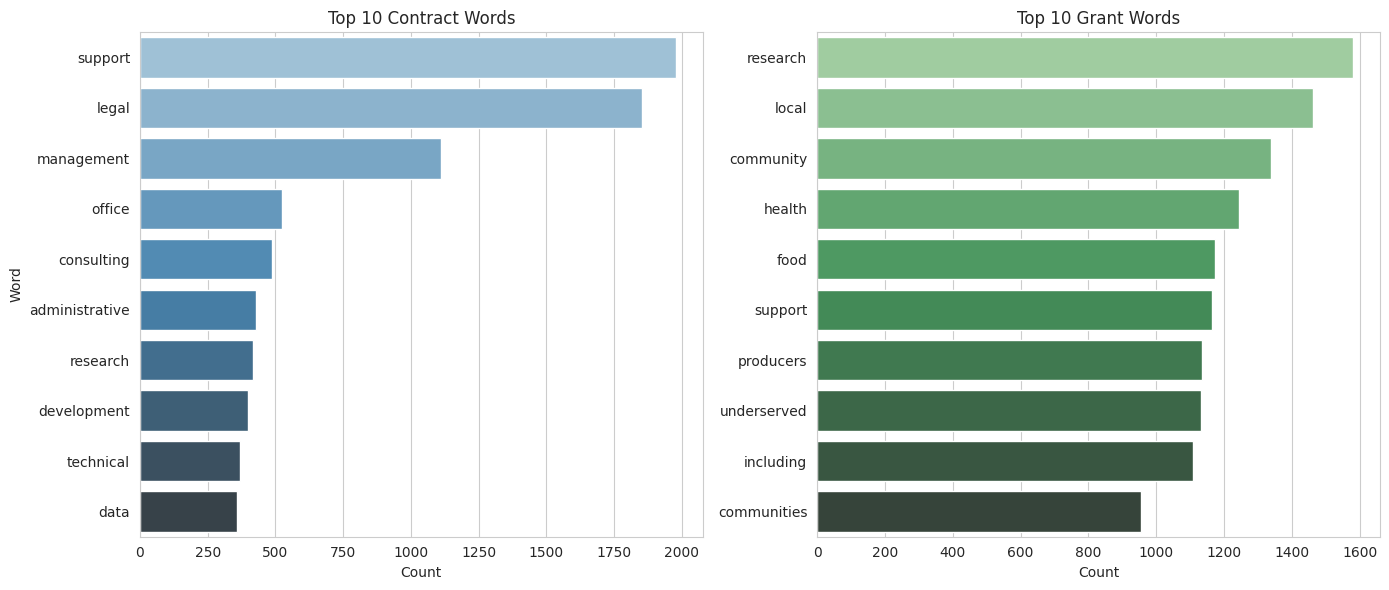

Saved combined top-10 bar plot to figures\top_10_words.png


In [ ]:
# Read top contract and grant words from CSV files
df_contract = pd.read_csv("data/top_contract_words.csv")
df_grant = pd.read_csv("data/top_grant_wrds.csv")

# Keep only top 10 words from each
df_contract = df_contract.head(10)
df_grant = df_grant.head(10)

# Create side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Plot contract words (left)
if not df_contract.empty:
    sns.barplot(y='word', x='count', data=df_contract, ax=axes[0], palette='Blues_d')
    axes[0].set_title('Top 10 Contract Words')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('Word')
else:
    axes[0].text(0.5, 0.5, 'No contract data', ha='center', va='center')
    axes[0].set_axis_off()

# Plot grant words (right)
if not df_grant.empty:
    sns.barplot(y='word', x='count', data=df_grant, ax=axes[1], palette='Greens_d')
    axes[1].set_title('Top 10 Grant Words')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel('')
else:
    axes[1].text(0.5, 0.5, 'No grant data', ha='center', va='center')
    axes[1].set_axis_off()

# Save and display
plt.tight_layout()
plt.savefig("data/top_10_words.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()

C:\Users\rosea\AppData\Local\Temp\ipykernel_40044\2616895673.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='word', x='count', data=df_contract, ax=axes[0], palette='Oranges_d')
C:\Users\rosea\AppData\Local\Temp\ipykernel_40044\2616895673.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='word', x='count', data=df_grant, ax=axes[1], palette='Purples_d')


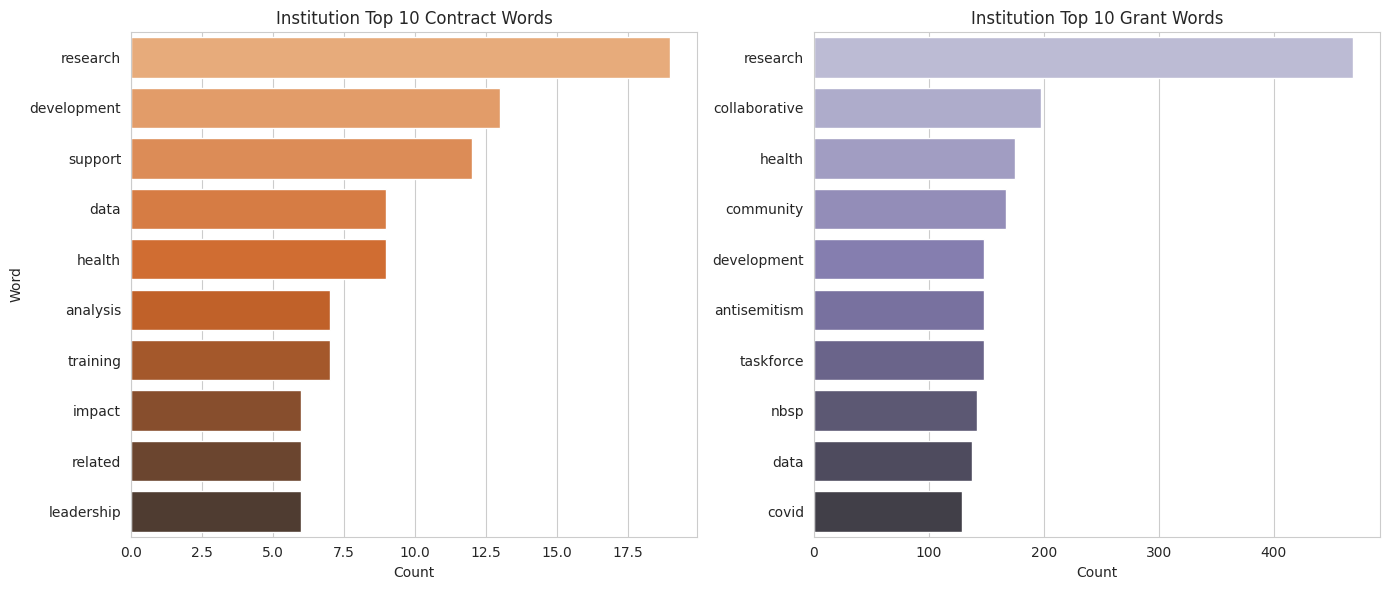

Saved combined institution top-10 bar plot to figures\institution_top_10_words.png


In [ ]:
# same as the last cell just with different colors and different dataframes

df_contract = pd.read_csv('data/institution_top_contract_words.csv')
df_grant = pd.read_csv('data/institution_top_grant_words.csv')
df_contract = df_contract.head(10)
df_grant = df_grant.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
if not df_contract.empty:
    sns.barplot(y='word', x='count', data=df_contract, ax=axes[0], palette='Oranges_d')
    axes[0].set_title('Institution Top 10 Contract Words')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('Word')
else:
    axes[0].text(0.5, 0.5, 'No institution contract data', ha='center', va='center')
    axes[0].set_axis_off()
if not df_grant.empty:
    sns.barplot(y='word', x='count', data=df_grant, ax=axes[1], palette='Purples_d')
    axes[1].set_title('Institution Top 10 Grant Words')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel('')
else:
    axes[1].text(0.5, 0.5, 'No institution grant data', ha='center', va='center')
    axes[1].set_axis_off()

plt.savefig('figures/institution_top_10_words.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()



In [8]:


# health / science words to look for
health_science_words = [
    'health','medical','medicine','clinical','clinic','hospital','patient','epidemiology','epidemiologic','disease',
    'infection','infectious','virus','viral','vaccine','vaccination','immunology','immunity','immuno',
    'biomedical','biotech','biotechnology','bio','biology','biological','genetic','genetics','genomics','genomic',
    'pharmacology','pharmaceutical','drug','therapeutic','therapy','trial','clinicaltrial','randomized',
    'oncology','cancer','cardiology','neurology','neuroscience','psychiatry','mental','public health','publichealth',
    'nurse','nursing','physician','doctor','surgeon','surgery','pathology','pathogen','microbiology','microbial',
    'virology','laboratory','lab','assay','sequencing','genome','geneticsequencing','bioinformatics','informatics',
    'research','researcher','study','studies','investigation','development','r&d','rnd','preclinical','pre-clinical',
    'manufacturing','production','diagnostic','diagnostics','screening','screen','monitoring','surveillance','outbreak','pandemic',
    'imaging','radiology','mri','ct','ultrasound','spectroscopy','microscopy','clinicaldata','electrophysiology','epigenetics',
    'toxicology','toxin','bioassay','assays','protocol','regulatory','compliance','cdc','nih','fda',
    'population','cohort','registry','biobank','specimen','sample','biospecimen','sequencer','therapeutics','antibody',
]

# normalize list to exactly 100 words
if len(health_science_words) < 100:
    health_science_words
elif len(health_science_words) > 100:
    # remove words from the end until exactly 100
    health_science_words = health_science_words[:100]

# enforce lowercase and unique
health_science_words = [w.lower() for w in health_science_words][:100]
health_science_words = list(dict.fromkeys(health_science_words))[:100]

df = pd.read_csv('data/clean_cuts.csv')

df['contract_n'] = df['contract_description'].fillna('').astype(str).str.lower()
df['grant_n'] = df['grant_description'].fillna('').astype(str).str.lower()

df['savings_num'] = df.get('savings').apply(parse_money)

# helper to match whole words (allow simple plural 's')
def word_mask_in_text(word, series):
    # compile once per word
    pat = re.compile(r"\b" + re.escape(word.lower()) + r"s?\b")
    return series.str.contains(pat, na=False)

# compute savings and counts per word in the 100-word list
word_savings = defaultdict(float)
word_counts = defaultdict(int)
for w in health_science_words:
    m = word_mask_in_text(w, df['contract_n']) | word_mask_in_text(w, df['grant_n'])
    c = int(m.sum())
    s = float(df.loc[m, 'savings_num'].sum()) if c > 0 else 0.0
    if c > 0:
        word_counts[w] = c
        word_savings[w] = s

# prepare results dataframe and top 10 by savings
results = pd.DataFrame([{'word': w, 'count': word_counts.get(w, 0), 'savings': word_savings.get(w, 0.0)} for w in health_science_words])
results = results.sort_values('savings', ascending=False).reset_index(drop=True)
top10 = results.head(10)

results.to_csv("data/health_science_word_savings.csv", index=False)

# print summary
print(f'Produced {len(health_science_words)} health/science keywords and saved per-word savings to {out}')
print('\nTop 10 health/science words by summed savings:')
print(top10.to_string(index=False))


Produced 100 health/science keywords and saved per-word savings to data\health_science_word_savings.csv

Top 10 health/science words by summed savings:
        word  count          savings
     disease    455 9,773,312,753.91
  laboratory    390 9,290,401,498.79
  infectious    325 9,057,377,618.58
epidemiology    293 8,937,797,683.80
     vaccine    356 6,876,391,911.22
 development   1164 5,944,901,773.72
      health   1060 5,486,790,400.46
    research   1643 3,862,453,303.06
  monitoring    261 3,378,990,504.80
  production    209 1,551,409,180.17


C:\Users\rosea\AppData\Local\Temp\ipykernel_40044\1710834806.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='savings', y='word', data=df_top, palette='viridis')


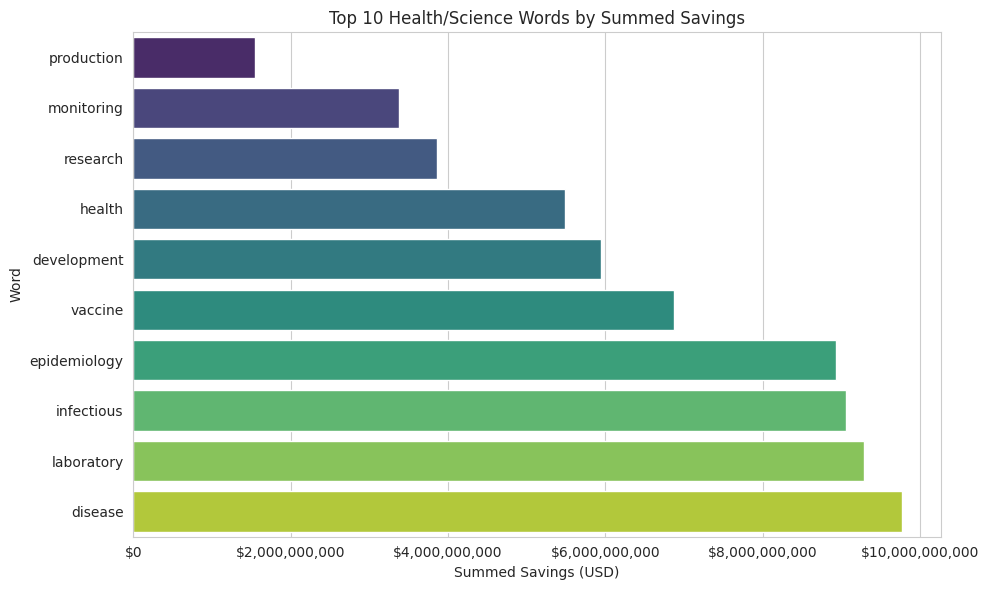

Saved top-10 health/science savings plot to figures\top10_health_savings.png


In [ ]:
# Read the health/science word savings data and get top 10 by savings
df_top = pd.read_csv("data/health_science_word_savings.csv")
df_top = df_top.sort_values('savings', ascending=False).head(10)

# Ensure numeric savings and sort ascending for horizontal barplot
df_top['savings'] = pd.to_numeric(df_top['savings'], errors='coerce').fillna(0.0)
df_top = df_top.sort_values('savings', ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(10,6))
ax = sns.barplot(x='savings', y='word', data=df_top, palette='viridis')
ax.set_title('Top 10 Health/Science Words by Summed Savings')
ax.set_xlabel('Summed Savings (USD)')
ax.set_ylabel('Word')

# Format x-axis with dollar signs and comma separators
fmt = FuncFormatter(lambda x, pos: f'${x:,.0f}')
ax.xaxis.set_major_formatter(fmt)

# Save and display the plot
plt.tight_layout()
plt.savefig("figures/top10_health_savings.png", dpi=150, bbox_inches='tight')
plt.show()